# AI-Art Forensics_5: Adversarial Robustness

## Cell 0 — Imports, load embeddings, retrain classifier

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.2)
COLORS = {
    'human'              : '#4C9BE8',
    'latent_diffusion'   : '#E87C4C',
    'standard_diffusion' : '#5CB85C'
}
OUT_DIR = '/kaggle/working'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

EMBED_PATH = None
META_PATH = None

for root, dirs, files in os.walk('/kaggle/input'):
    if 'embeddings.npy' in files and 'metadata.csv' in files:
        EMBED_PATH = os.path.join(root, 'embeddings.npy')
        META_PATH = os.path.join(root, 'metadata.csv')
        break

if EMBED_PATH is None:
    print('ERROR: Could not find embeddings.npy and metadata.csv.')
    print('\nAvailable Kaggle inputs:')
    for root, dirs, files in os.walk('/kaggle/input'):
        print(root)
        for file in files:
            print('   ', file)
else:
    print(f'Embeddings path: {EMBED_PATH}')
    print(f'Metadata path:   {META_PATH}')

E    = np.load(EMBED_PATH).astype(np.float32)
meta = pd.read_csv(META_PATH)
meta['style'] = meta['style'].str.replace('-', '_')
print(f'Embeddings: {E.shape}')

train_mask = meta['split'] == 'train'
test_mask  = meta['split'] == 'test'
X_train = E[train_mask];  y_train = meta.loc[train_mask, 'label'].values
X_test  = E[test_mask];   y_test  = meta.loc[test_mask,  'label'].values
src_test = meta.loc[test_mask, 'source'].values
sty_test = meta.loc[test_mask, 'style'].values

clf = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                          random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
clean_acc = accuracy_score(y_test, clf.predict(X_test))
print(f'Clean accuracy (baseline): {clean_acc*100:.2f}%')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

W = torch.tensor(clf.coef_[0], dtype=torch.float32).to(DEVICE)  
b = torch.tensor(clf.intercept_[0], dtype=torch.float32).to(DEVICE)

Embeddings path: /kaggle/input/notebooks/merjendursunova/clip-embedding-extraction/embeddings.npy
Metadata path:   /kaggle/input/notebooks/merjendursunova/clip-embedding-extraction/metadata.csv
Embeddings: (185015, 512)
Clean accuracy (baseline): 99.49%
Device: cpu


FGSM Attack in Embedding Space

In [2]:
def fgsm_embedding(X, y, W, b, epsilon):
    
    X_t   = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    y_t   = torch.tensor(y, dtype=torch.float32).to(DEVICE)
    W_norm = W / (W.norm() + 1e-8)   
    
    direction = torch.where(
        y_t.unsqueeze(1).expand_as(X_t) == 1,
        -W_norm.unsqueeze(0).expand_as(X_t),   
         W_norm.unsqueeze(0).expand_as(X_t)    
    )
    X_adv = X_t + epsilon * direction

    
    X_adv = X_adv / (X_adv.norm(dim=1, keepdim=True) + 1e-8)
    return X_adv.cpu().numpy()


epsilons     = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]
fgsm_results = []

for eps in epsilons:
    if eps == 0.0:
        acc = clean_acc
    else:
        X_adv = fgsm_embedding(X_test, y_test, W, b, eps)
        acc   = accuracy_score(y_test, clf.predict(X_adv))
    fgsm_results.append({'epsilon': eps, 'accuracy': acc})
    print(f'  ε={eps:.3f}  →  accuracy={acc*100:.2f}%')

fgsm_df = pd.DataFrame(fgsm_results)

  ε=0.000  →  accuracy=99.49%
  ε=0.010  →  accuracy=98.83%
  ε=0.020  →  accuracy=97.61%
  ε=0.050  →  accuracy=85.73%
  ε=0.100  →  accuracy=34.62%
  ε=0.200  →  accuracy=0.02%
  ε=0.300  →  accuracy=0.00%
  ε=0.500  →  accuracy=0.00%


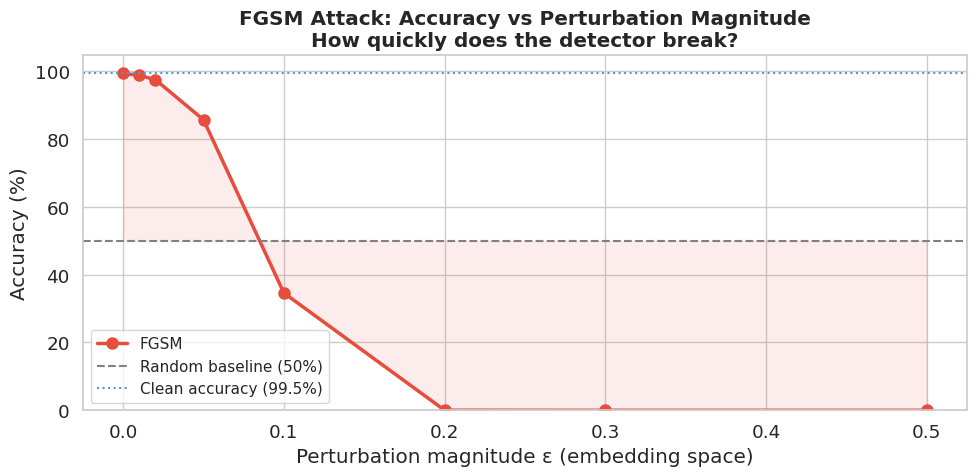

Accuracy drops below 80% at ε = 0.1


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fgsm_df['epsilon'], fgsm_df['accuracy'] * 100,
        'o-', color='#E74C3C', linewidth=2.5, markersize=8, label='FGSM')
ax.axhline(y=50, color='gray', linestyle='--', lw=1.5, label='Random baseline (50%)')
ax.axhline(y=clean_acc*100, color='#4C9BE8', linestyle=':', lw=1.5,
           label=f'Clean accuracy ({clean_acc*100:.1f}%)')
ax.fill_between(fgsm_df['epsilon'], fgsm_df['accuracy']*100, 50,
                alpha=0.1, color='#E74C3C')
ax.set_xlabel('Perturbation magnitude ε (embedding space)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('FGSM Attack: Accuracy vs Perturbation Magnitude\n'
             'How quickly does the detector break?', fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/15_fgsm_curve.png', dpi=150, bbox_inches='tight')
plt.show()

below_80 = fgsm_df[fgsm_df['accuracy'] < 0.80]
if len(below_80) > 0:
    print(f'Accuracy drops below 80% at ε = {below_80.iloc[0]["epsilon"]}')
else:
    print('Accuracy stays above 80% across all tested epsilon values.')

PGD Attack in Embedding Space

In [4]:
def pgd_embedding(X, y, W, b, epsilon, n_steps=20, step_size=None):
   
    if step_size is None:
        step_size = epsilon / 4

    X_t   = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    y_t   = torch.tensor(y, dtype=torch.float32).to(DEVICE)
    W_norm = W / (W.norm() + 1e-8)

    
    X_adv = X_t + torch.zeros_like(X_t).uniform_(-epsilon, epsilon)
    X_adv = X_adv / (X_adv.norm(dim=1, keepdim=True) + 1e-8)

    for _ in range(n_steps):
        direction = torch.where(
            y_t.unsqueeze(1).expand_as(X_t) == 1,
            -W_norm.unsqueeze(0).expand_as(X_t),
             W_norm.unsqueeze(0).expand_as(X_t)
        )
        X_adv = X_adv + step_size * direction

        
        delta = X_adv - X_t
        delta_norm = delta.norm(dim=1, keepdim=True).clamp(min=epsilon)
        delta = delta * epsilon / delta_norm
        X_adv = X_t + delta

        
        X_adv = X_adv / (X_adv.norm(dim=1, keepdim=True) + 1e-8)

    return X_adv.cpu().numpy()


epsilons_pgd = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]
pgd_results  = []

for eps in tqdm(epsilons_pgd, desc='PGD attack'):
    if eps == 0.0:
        acc = clean_acc
    else:
        X_adv = pgd_embedding(X_test, y_test, W, b, epsilon=eps, n_steps=20)
        acc   = accuracy_score(y_test, clf.predict(X_adv))
    pgd_results.append({'epsilon': eps, 'accuracy': acc})
    print(f'  ε={eps:.3f}  →  PGD accuracy={acc*100:.2f}%')

pgd_df = pd.DataFrame(pgd_results)

PGD attack:   0%|          | 0/8 [00:00<?, ?it/s]

  ε=0.000  →  PGD accuracy=99.49%
  ε=0.010  →  PGD accuracy=98.83%
  ε=0.020  →  PGD accuracy=97.61%
  ε=0.050  →  PGD accuracy=85.75%
  ε=0.100  →  PGD accuracy=34.74%
  ε=0.200  →  PGD accuracy=0.02%
  ε=0.300  →  PGD accuracy=0.00%
  ε=0.500  →  PGD accuracy=0.00%


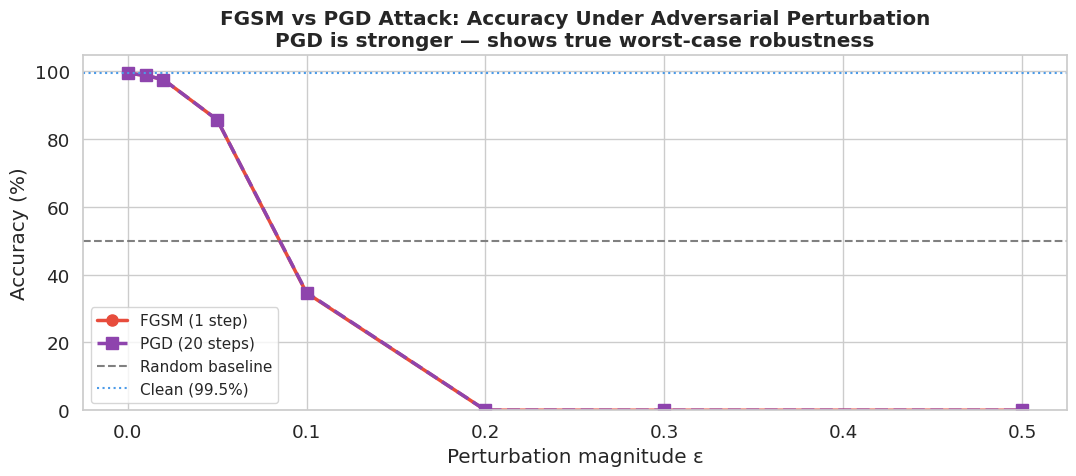

In [5]:

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(fgsm_df['epsilon'], fgsm_df['accuracy']*100,
        'o-', color='#E74C3C', lw=2.5, ms=8, label='FGSM (1 step)')
ax.plot(pgd_df['epsilon'],  pgd_df['accuracy']*100,
        's--', color='#8E44AD', lw=2.5, ms=8, label='PGD (20 steps)')
ax.axhline(y=50, color='gray', linestyle='--', lw=1.5, label='Random baseline')
ax.axhline(y=clean_acc*100, color='#4C9BE8', linestyle=':', lw=1.5,
           label=f'Clean ({clean_acc*100:.1f}%)')
ax.set_xlabel('Perturbation magnitude ε')
ax.set_ylabel('Accuracy (%)')
ax.set_title('FGSM vs PGD Attack: Accuracy Under Adversarial Perturbation\n'
             'PGD is stronger — shows true worst-case robustness',
             fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/16_fgsm_vs_pgd.png', dpi=150, bbox_inches='tight')
plt.show()

Pixel-Space FGSM Attack

In [6]:
!pip install -q git+https://github.com/openai/CLIP.git
import clip
clip_model, preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
print('CLIP loaded for pixel-space attacks.')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 171MiB/s]


CLIP loaded for pixel-space attacks.


In [7]:
def pixel_fgsm(img_path, true_label, clip_model, preprocess, clf, epsilon=0.02):
    
    with torch.no_grad():
        img_clean = preprocess(
            Image.open(img_path).convert('RGB')
        ).unsqueeze(0).to(DEVICE).float()
        clean_emb = clip_model.encode_image(img_clean).float()
        clean_emb = clean_emb / (clean_emb.norm() + 1e-8)

    
    img_tensor = preprocess(
        Image.open(img_path).convert('RGB')
    ).unsqueeze(0).to(DEVICE).float()
    img_tensor.requires_grad_(True)

    emb      = clip_model.encode_image(img_tensor).float()
    emb_norm = emb / (emb.norm() + 1e-8)

    W_t   = torch.tensor(clf.coef_[0], dtype=torch.float32).to(DEVICE)
    score = emb_norm @ W_t
    loss  = score if true_label == 1 else -score

    clip_model.zero_grad()
    loss.backward()

    img_adv = img_tensor + epsilon * img_tensor.grad.data.sign()
    img_adv = torch.clamp(img_adv,
                          img_tensor.detach() - epsilon,
                          img_tensor.detach() + epsilon)

    with torch.no_grad():
        adv_emb = clip_model.encode_image(img_adv.detach()).float()
        adv_emb = adv_emb / (adv_emb.norm() + 1e-8)

    return (clean_emb.cpu().numpy(),
            adv_emb.cpu().numpy(),
            img_adv.detach().cpu().numpy())


clip_model = clip_model.float()

N_PIXEL_TEST = 200   
pixel_results = []
for src in ['human', 'latent_diffusion', 'standard_diffusion']:
    subset = meta[(meta['split'] == 'test') & (meta['source'] == src)].sample(
        N_PIXEL_TEST, random_state=42)
    correct_clean = 0
    correct_adv   = 0
    errors = []
    for _, row in tqdm(subset.iterrows(), total=N_PIXEL_TEST, desc=src):
        try:
            clean_emb, adv_emb, _ = pixel_fgsm(
                row['path'], row['label'], clip_model, preprocess, clf, epsilon=0.02)
            pred_clean = int(clf.predict(clean_emb.reshape(1, -1))[0])
            pred_adv   = int(clf.predict(adv_emb.reshape(1, -1))[0])
            correct_clean += int(pred_clean == row['label'])
            correct_adv   += int(pred_adv   == row['label'])
        except Exception as e:
            errors.append(str(e))

    unique_errors = list(set(errors))[:3]
    print(f'\n{src} — {len(errors)} errors out of {N_PIXEL_TEST}')
    for err in unique_errors:
        print(f'  ERROR: {err}')

    pixel_results.append({
        'source'    : src,
        'clean_acc' : correct_clean / N_PIXEL_TEST,
        'adv_acc'   : correct_adv   / N_PIXEL_TEST,
        'acc_drop'  : (correct_clean - correct_adv) / N_PIXEL_TEST
    })

pixel_df = pd.DataFrame(pixel_results)
print('\nPixel-space FGSM results (ε=0.02):')
print(pixel_df.to_string(index=False))

human:   0%|          | 0/200 [00:00<?, ?it/s]


human — 0 errors out of 200


latent_diffusion:   0%|          | 0/200 [00:00<?, ?it/s]


latent_diffusion — 0 errors out of 200


standard_diffusion:   0%|          | 0/200 [00:00<?, ?it/s]


standard_diffusion — 0 errors out of 200

Pixel-space FGSM results (ε=0.02):
            source  clean_acc  adv_acc  acc_drop
             human       0.99    1.000    -0.010
  latent_diffusion       0.99    0.995    -0.005
standard_diffusion       1.00    1.000     0.000


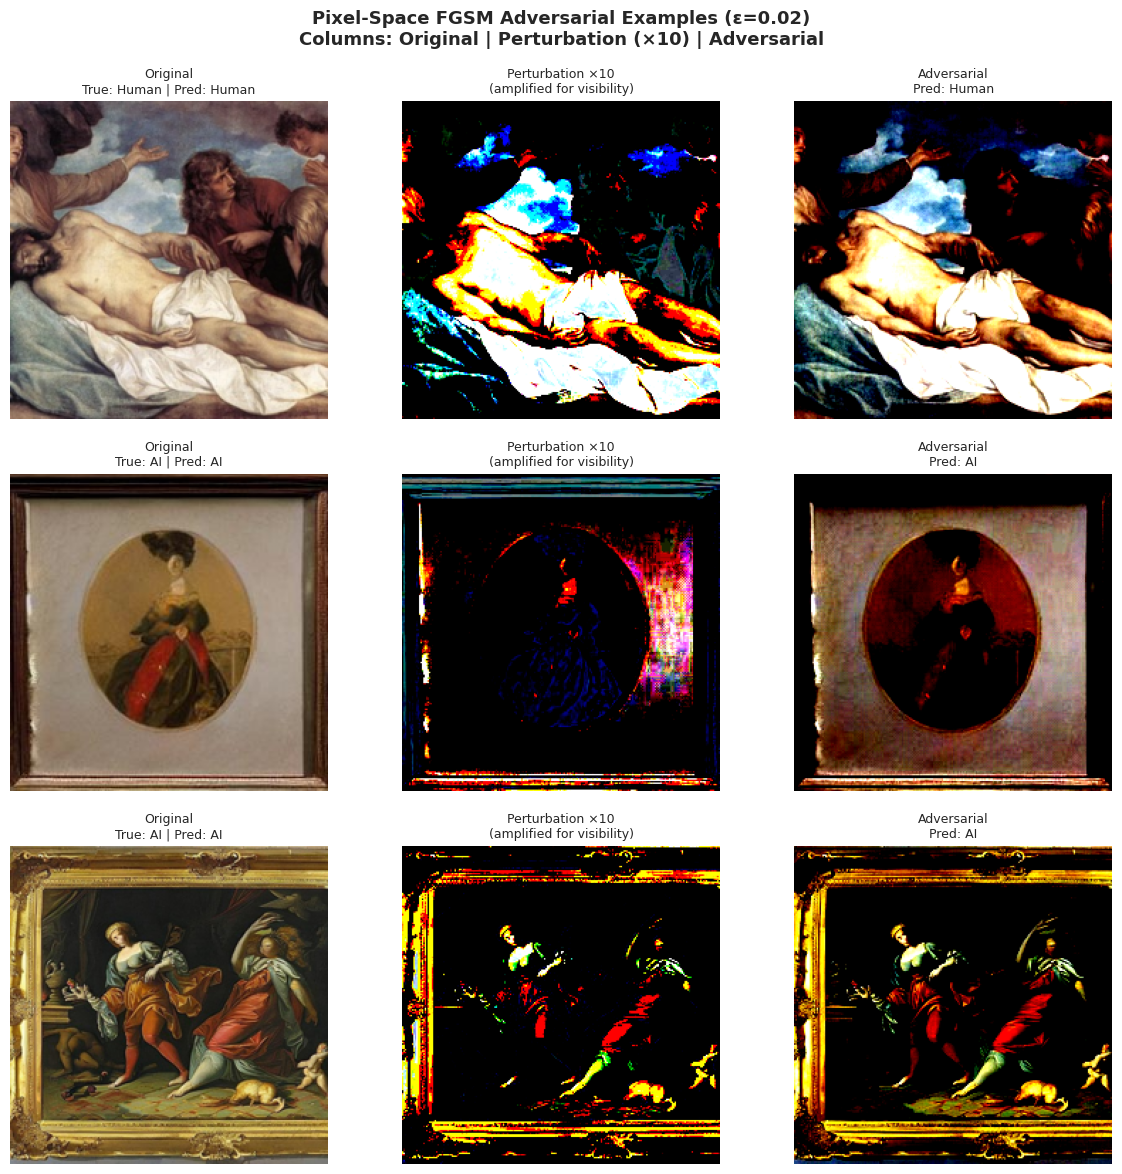

In [8]:

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Pixel-Space FGSM Adversarial Examples (ε=0.02)\n'
             'Columns: Original | Perturbation (×10) | Adversarial',
             fontweight='bold', fontsize=13)

for row_idx, src in enumerate(['human', 'latent_diffusion', 'standard_diffusion']):
    sample = meta[(meta['split'] == 'test') &
                  (meta['source'] == src)].sample(1, random_state=7).iloc[0]
    try:
        clean_emb, adv_emb, adv_tensor = pixel_fgsm(
            sample['path'], sample['label'], clip_model, preprocess, clf, epsilon=0.02)

        orig_img  = Image.open(sample['path']).convert('RGB').resize((224, 224))
        orig_arr  = np.array(orig_img) / 255.0

        
        adv_arr   = adv_tensor[0].transpose(1, 2, 0)  
        adv_arr   = np.clip(adv_arr, 0, 1)

        
        if orig_arr.shape != adv_arr.shape:
            orig_arr = np.array(
                Image.fromarray((orig_arr * 255).astype(np.uint8)).resize(
                    (adv_arr.shape[1], adv_arr.shape[0])))
            orig_arr = orig_arr / 255.0

        perturbation = np.clip((adv_arr - orig_arr) * 10 + 0.5, 0, 1)

        pred_clean = clf.predict(clean_emb.reshape(1,-1))[0]
        pred_adv   = clf.predict(adv_emb.reshape(1,-1))[0]
        label_map  = {0: 'Human', 1: 'AI'}

        axes[row_idx, 0].imshow(orig_arr)
        axes[row_idx, 0].set_title(
            f'Original\nTrue: {label_map[sample["label"]]} | Pred: {label_map[pred_clean]}',
            fontsize=9)
        axes[row_idx, 1].imshow(perturbation)
        axes[row_idx, 1].set_title('Perturbation ×10\n(amplified for visibility)', fontsize=9)
        axes[row_idx, 2].imshow(adv_arr)
        axes[row_idx, 2].set_title(
            f'Adversarial\nPred: {label_map[pred_adv]}', fontsize=9)
        for ax in axes[row_idx]:
            ax.axis('off')
    except Exception as ex:
        print(f'Visualization failed for {src}: {ex}')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/17_adversarial_examples.png', dpi=150, bbox_inches='tight')
plt.show()

Adversarial Training

In [9]:
%%time

EPS_TRAIN = 0.05   
EPS_TEST  = 0.05   

print('Generating FGSM training augmentation...')
X_fgsm_train = fgsm_embedding(X_train, y_train, W, b, EPS_TRAIN)

print('Generating PGD training augmentation...')
X_pgd_train  = pgd_embedding(X_train, y_train, W, b,
                              epsilon=EPS_TRAIN, n_steps=10)


print('Generating adversarial test sets...')
X_fgsm_test  = fgsm_embedding(X_test, y_test, W, b, EPS_TEST)
X_pgd_test   = pgd_embedding(X_test, y_test, W, b,
                              epsilon=EPS_TEST, n_steps=20)
print('Done.')

Generating FGSM training augmentation...
Generating PGD training augmentation...
Generating adversarial test sets...
Done.
CPU times: user 17.2 s, sys: 26.4 s, total: 43.6 s
Wall time: 23 s


In [10]:
def train_and_eval(X_tr, y_tr, name=''):
    """Train logistic regression and evaluate on clean + adversarial test sets."""
    m = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                           random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)
    return {
        'model'    : name,
        'clean'    : accuracy_score(y_test,       m.predict(X_test)),
        'fgsm_005' : accuracy_score(y_test,       m.predict(X_fgsm_test)),
        'pgd_005'  : accuracy_score(y_test,       m.predict(X_pgd_test)),
    }


r_clean = train_and_eval(X_train, y_train, 'Clean only')


X_aug_fgsm = np.concatenate([X_train, X_fgsm_train])
y_aug_fgsm = np.concatenate([y_train, y_train])
r_fgsm = train_and_eval(X_aug_fgsm, y_aug_fgsm, 'Clean + FGSM')


X_aug_pgd = np.concatenate([X_train, X_pgd_train])
y_aug_pgd = np.concatenate([y_train, y_train])
r_pgd = train_and_eval(X_aug_pgd, y_aug_pgd, 'Clean + PGD')

results_df = pd.DataFrame([r_clean, r_fgsm, r_pgd])
print('Adversarial training results:')
print(results_df.to_string(index=False))

Adversarial training results:
       model    clean  fgsm_005  pgd_005
  Clean only 0.994900  0.857333 0.857500
Clean + FGSM 0.984133  0.902400 0.902433
 Clean + PGD 0.985200  0.901500 0.901667


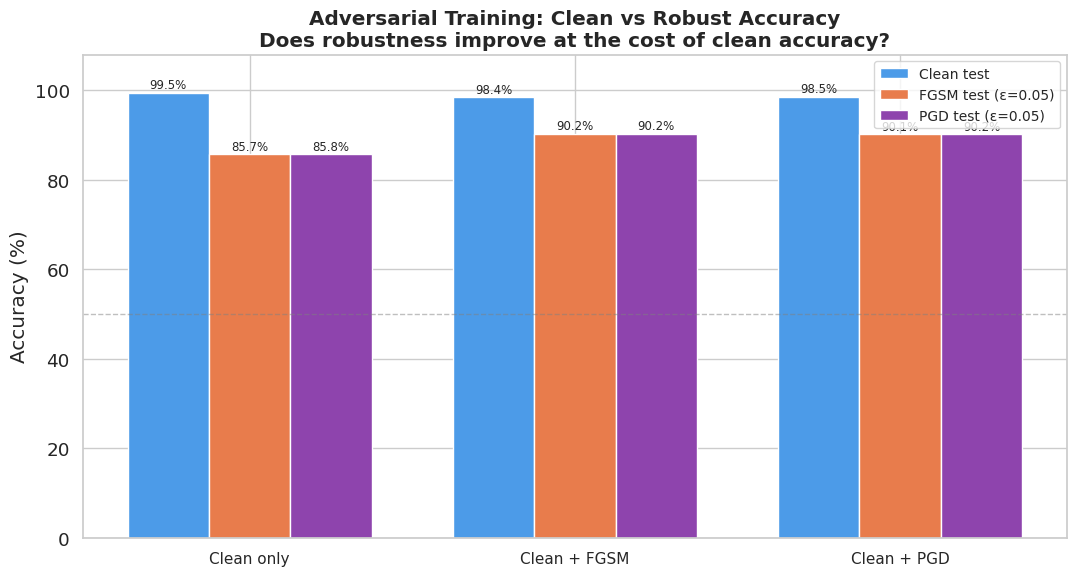

In [11]:

fig, ax = plt.subplots(figsize=(11, 6))

x      = np.arange(3)
width  = 0.25
colors = ['#4C9BE8', '#E87C4C', '#8E44AD']
cols   = ['clean', 'fgsm_005', 'pgd_005']
labels = ['Clean test', 'FGSM test (ε=0.05)', 'PGD test (ε=0.05)']

for i, (col, label, color) in enumerate(zip(cols, labels, colors)):
    vals = results_df[col].values * 100
    bars = ax.bar(x + i*width, vals, width, label=label,
                  color=color, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df['model'], fontsize=11)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 108)
ax.set_title('Adversarial Training: Clean vs Robust Accuracy\n'
             'Does robustness improve at the cost of clean accuracy?',
             fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=50, color='gray', linestyle='--', lw=1, alpha=0.5)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/18_adversarial_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Final Summary

In [12]:


print(f'\nClean accuracy                : {clean_acc*100:.2f}%')


fgsm_drop = fgsm_df[fgsm_df['epsilon'] == 0.05]['accuracy'].values
if len(fgsm_drop):
    print(f'FGSM accuracy (ε=0.05)        : {fgsm_drop[0]*100:.2f}%  '
          f'(drop: {(clean_acc - fgsm_drop[0])*100:.1f}pp)')

pgd_drop = pgd_df[pgd_df['epsilon'] == 0.05]['accuracy'].values
if len(pgd_drop):
    print(f'PGD accuracy  (ε=0.05)        : {pgd_drop[0]*100:.2f}%  '
          f'(drop: {(clean_acc - pgd_drop[0])*100:.1f}pp)')

print(f'\nPixel-space FGSM (ε=0.02):')
for _, row in pixel_df.iterrows():
    print(f'  {row.source:25s}: {row.clean_acc*100:.1f}% → {row.adv_acc*100:.1f}% '
          f'(drop: {row.acc_drop*100:.1f}pp)')

print(f'\nAdversarial training results:')
for _, row in results_df.iterrows():
    print(f'  {row.model:20s}: clean={row.clean*100:.1f}% | '
          f'fgsm={row.fgsm_005*100:.1f}% | pgd={row.pgd_005*100:.1f}%')




Clean accuracy                : 99.49%
FGSM accuracy (ε=0.05)        : 85.73%  (drop: 13.8pp)
PGD accuracy  (ε=0.05)        : 85.75%  (drop: 13.7pp)

Pixel-space FGSM (ε=0.02):
  human                    : 99.0% → 100.0% (drop: -1.0pp)
  latent_diffusion         : 99.0% → 99.5% (drop: -0.5pp)
  standard_diffusion       : 100.0% → 100.0% (drop: 0.0pp)

Adversarial training results:
  Clean only          : clean=99.5% | fgsm=85.7% | pgd=85.8%
  Clean + FGSM        : clean=98.4% | fgsm=90.2% | pgd=90.2%
  Clean + PGD         : clean=98.5% | fgsm=90.1% | pgd=90.2%


In [13]:
import joblib


clf_robust = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                 random_state=42, n_jobs=-1)
clf_robust.fit(X_aug_fgsm, y_aug_fgsm)

joblib.dump(clf_robust, f'{OUT_DIR}/classifier.joblib')
print(f'Classifier saved → {OUT_DIR}/classifier.joblib')


umap_sample = 5000
rng = np.random.default_rng(42)
umap_idx = rng.choice(len(E), size=umap_sample, replace=False)

np.save(f'{OUT_DIR}/umap_embeddings_sample.npy', E[umap_idx])
meta.iloc[umap_idx].to_csv(f'{OUT_DIR}/umap_meta_sample.csv', index=False)
print(f'UMAP reference data saved ({umap_sample} points)')

Classifier saved → /kaggle/working/classifier.joblib
UMAP reference data saved (5000 points)
